<a href="https://colab.research.google.com/github/marcosfellet/UFJF/blob/main/Resposta_ao_Degrau_Unit%C3%A1rio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho 2 (CEL112 B)**

## **Grupo:**


1.   Alice Oliveira Junqueira de Sousa (202369011B)
2.   Marcos Brandão Fellet (202169009A)
3.   Maria Eduarda Lambert (202565402JO)

In [ ]:
!pip install control
import control as ct
import numpy as np
import sympy as sp
from sympy.integrals.transforms import inverse_laplace_transform as ilt
!pip install --upgrade pip
import control
import math
from control import series
from sympy import symbols, simplify
from IPython.display import display, Math
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


Função de transferência no domínio da frequência

In [ ]:
# função auxiliar para converter de control.TransferFunction para sympy
def tf_to_sympy(tf):
    s = symbols('s')
    num, den = tf.num[0][0], tf.den[0][0]
    num_poly = sum(num[i] * s**(len(num)-i-1) for i in range(len(num)))
    den_poly = sum(den[i] * s**(len(den)-i-1) for i in range(len(den)))
    return simplify(num_poly/den_poly)




# Numerador e denominador da função de transferência G(s) e do degrau unitário U(s)
num = [0, 0, 16]
den = [1, 4, 16]
num_degrau = [0, 1]
den_degrau = [1, 0]

# Função de transferência G(s)
G = ct.tf(num, den)

# Degrau unitário
U = ct.tf(num_degrau, den_degrau)

# Sistema com o degrau unitário aplicado na entrada:

C = ct.series(U, G)

C_s = tf_to_sympy(C)

# Exibe o sistema
latex_sistema = (r"\text{C(s)} = " + sp.latex(C_s))

display(Math(latex_sistema))


<IPython.core.display.Math object>

Para a transformada inversa de Laplace:

In [ ]:
# Definindo as variaveis:
t = sp.symbols('t', real=True, positive=True)
s = sp.symbols('s')

# Transformada inversa:

c_t = ilt(C_s, s, t)

# Exibe o resultado
display(Math(r'\text{c(t)} = ' + sp.latex(c_t)))

<IPython.core.display.Math object>

Calculando parâmetros requisitados no tempo:

In [ ]:
# variaveis:
t = np.arange(0, 4, 0.01) # de 0s, até 4s com passo 10ms
# função c(t) numericamente:
c = 1 - (np.sqrt(3)*np.exp(-2*t)*np.sin(2*np.sqrt(3)*t))/3 - np.exp(-2*t)*np.cos(2*np.sqrt(3)*t)

#########################################################################################################################
#################################### Encontrando parâmetros de interesse: ###############################################
#########################################################################################################################


# Tempo de pico
t_pico = t[np.argmax(c)]

# Valor de regime (média dos últimos pontos)
c_regime = np.mean(c[-20:])  # média dos últimos 0.2s

# Tempo de acomodação (5%)
tolerancia = 0.05  # 5% do valor de regime
faixa_superior = c_regime * (1 + tolerancia)
faixa_inferior = c_regime * (1 - tolerancia)

t_s = None
for i in range(len(t)):
    # Verifica se todos os pontos restantes estão dentro da faixa
    if np.all((c[i:] <= faixa_superior) & (c[i:] >= faixa_inferior)):
        t_s = t[i]
        break

if t_s is None:
    t_s = t[-1]  # se nunca estabilizar dentro do intervalo
    print("\n Não estabilizou dentro do intervalo \n")

# Máximo Sobressinal (%)

Mp = (c[np.argmax(c)] - c_regime)/c_regime *100

# Parâmetros na frequência:

# Comparando C(s) com a forma padrão da TF de segundo grau:
omega_n = 4
amortecimento = 0.5
omega_d = omega_n*np.sqrt(1- amortecimento**2)

print("="*60)
print("Parâmetros no tempo")
print("="*60)

print(f"Tempo de pico = {t_pico:.4f} s")
print(f"Tempo de acomodação (5%) = {t_s:.4f} s")
print(f"Máximo Sobressinal = {Mp:.2f}%")

print("="*60)
print("Parâmetros na frequência")
print("="*60)

print(f"Frequência natural do sistema = {omega_n:.2f} rad/s")
print(f"Coeficiente de amortecimento = {amortecimento:.2f} ")
print(f"Frequência natural amortecida = {omega_d:.2f} rad/s")







Parâmetros no tempo
Tempo de pico = 0.9100 s
Tempo de acomodação (5%) = 1.3300 s
Máximo Sobressinal = 16.35%
Parâmetros na frequência
Frequência natural do sistema = 4.00 rad/s
Coeficiente de amortecimento = 0.50 
Frequência natural amortecida = 3.46 rad/s


Plot da função no tempo, para fins de visualização dos resultados obtidos:

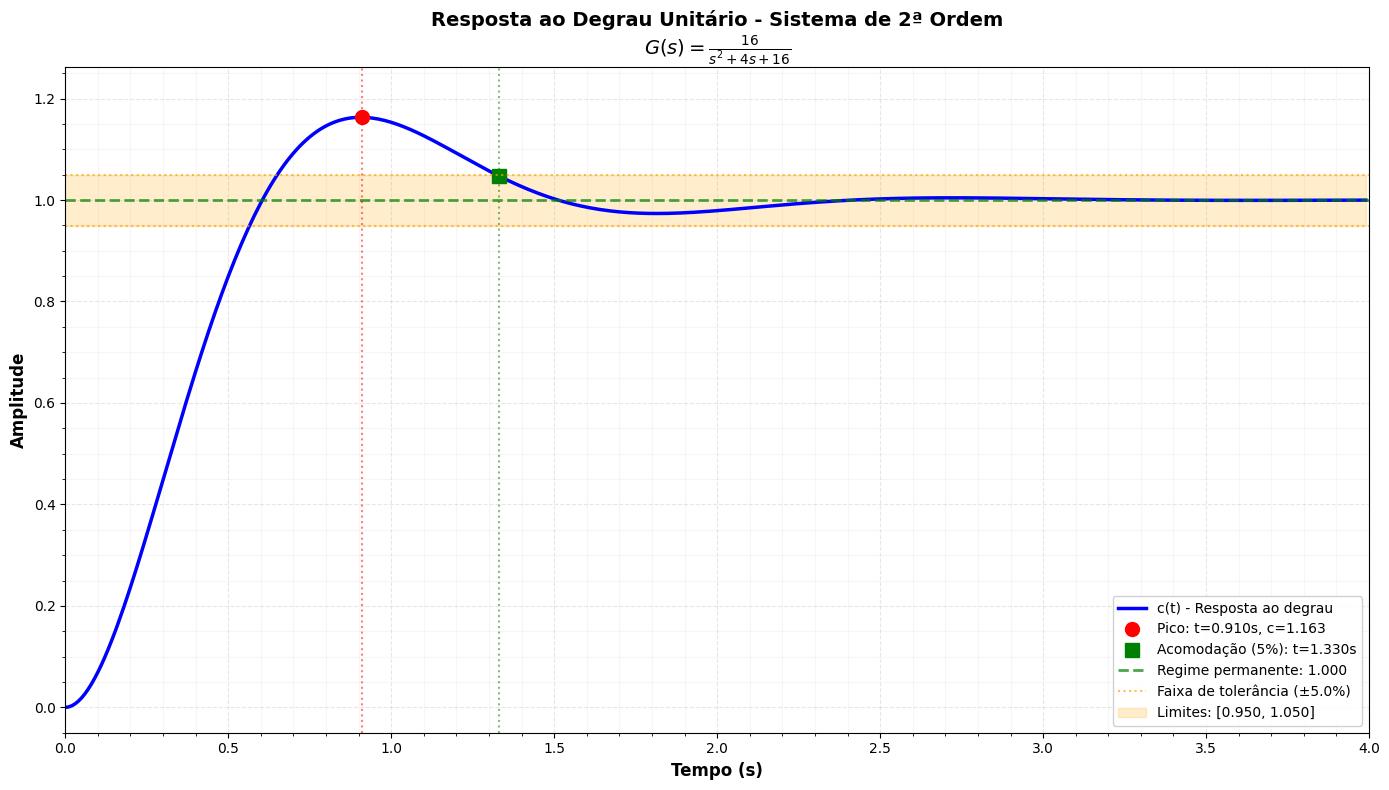

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

# Resposta c(t)
ax.plot(t, c, 'b-', linewidth=2.5, label='c(t) - Resposta ao degrau')

# Ponto de pico
ax.plot(t_pico, c[np.argmax(c)], 'ro', markersize=10, label=f'Pico: t={t_pico:.3f}s, c={c[np.argmax(c)]:.3f}')

# Ponto de acomodação
ax.plot(t_s, c[np.where(t == t_s)[0][0]], 'gs', markersize=10,
        label=f'Acomodação (5%): t={t_s:.3f}s')

# Linhas do valor de regime
ax.axhline(y=c_regime, color='g', linestyle='--', linewidth=2,
           alpha=0.7, label=f'Regime permanente: {c_regime:.3f}')

# Faixa de tolerância (5%)
ax.axhline(y=faixa_superior, color='orange', linestyle=':', linewidth=1.5,
           alpha=0.7, label=f'Faixa de tolerância (±{tolerancia*100}%)')
ax.axhline(y=faixa_inferior, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)

# Faixa de tolerância
ax.fill_between(t, faixa_inferior, faixa_superior, alpha=0.2, color='orange',
                label=f'Limites: [{faixa_inferior:.3f}, {faixa_superior:.3f}]')

# Linhas verticais para destacar os tempos
ax.axvline(x=t_pico, color='r', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axvline(x=t_s, color='g', linestyle=':', alpha=0.5, linewidth=1.5)

ax.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Resposta ao Degrau Unitário - Sistema de 2ª Ordem\n' +
             r'$G(s) = \frac{16}{s^2 + 4s + 16}$',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=10, framealpha=0.9)
ax.set_xlim([0, len(c)/100])
ax.set_ylim([min(c) - 0.05, max(c) + 0.1])
ax.grid(True, which='minor', alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

Observação: IA foi utilizada **SOMENTE** para gerar código bruto para exibição do gráfico. O algoritmo foi então, refinado pelos integrantes do grupo.